# 04. Fine-tuned vs foundation vs from-scratch MACE: ionic transport in four conductors

For each material, MD was run with three MACE models (training curves in notebook 01):

* **MACE fine-tuned** from MACE-MPA-0 (medium) on the material's own AIMD data,
* **MACE-MPA-0 (medium)**, the foundation model without fine-tuning,
* **MACE from scratch**, trained only on the same AIMD data.

| key | composition (cell) | mobile ion |
|---|---|---|
| LYC | Li<sub>15</sub>Y<sub>7</sub>Cl<sub>36</sub> (58 atoms) | Li |
| 20258 | Na<sub>9</sub>Y<sub>6</sub>Si<sub>3</sub>P<sub>9</sub>O<sub>42</sub> (69 atoms) | Na |
| 45802 | Na<sub>5</sub>Nb<sub>5</sub>W<sub>11</sub>O<sub>48</sub> (69 atoms) | Na |
| 75421 | Na<sub>11</sub>Si<sub>11</sub>Sb<sub>16</sub>As<sub>5</sub>O<sub>80</sub> (123 atoms) | Na |

**MD.** NVT with a Nosé–Hoover thermostat (ASE `NPT` integrator without barostat, τ<sub>T</sub> = 100 fs),
1 fs time step, 400,000 steps (400 ps), frames every 100 fs, 29 temperatures from 300 to 1000 K.
Each run starts from the last frame of a short temperature ramp; the first 10 ps are discarded.
Some MACE-MPA-0 runs stopped before 400 ps (wall-time limit); their analyzed length is listed.

### Diffusion analysis (same for every MD notebook in this repository)

Implemented in `iondiff/` (adapted from the MoGroup diffusion module; method of X. He, Y. Zhu, A. Epstein,
Y. Mo, *npj Comput. Mater.* **4**, 18 (2018)):

* **Trajectory**: jobs that continue a previous job (first frame identical to the previous last frame)
  are concatenated after dropping the duplicated frame; equilibration frames are removed only at the
  start of each chain. NPT displacements use each frame's own cell.
* **MSD**: time-averaged (FFT) mean squared displacement of the mobile ion, with the framework
  centre-of-mass drift removed; fitted linearly between MSD = 0.5 a² and 0.8 of the trajectory length
  (a = 3.38 Å, average hop distance), requiring at least 0.5 a² of MSD change. D = slope / 6.
* **Statistical error of D**: RSD = 3.43 / √N<sub>jump</sub> + 0.04 with N<sub>jump</sub> = n<sub>ions</sub>
  · max(MSD) / a² (He et al. 2018); σ<sub>D</sub> = RSD · D.
* **Framework melting**: a temperature is marked *melted* when the framework (all non-mobile atoms)
  diffuses, i.e. their time-averaged MSD at the end of the fit window exceeds a². Isolated framework
  hops (a few atoms moving > 4 Å) do not count; they are recorded separately.
* **Arrhenius fit (primary)**: least squares on log<sub>10</sub>D vs 1000/T, weighted by
  σ<sub>log10 D</sub>, using temperatures where the MSD fit succeeded and the framework did not melt.
  Fits that keep melted temperatures, and unweighted fits, are shown for comparison.
* **Conductivity**: Nernst–Einstein, σ = n z² e² D / (V k<sub>B</sub> T); σ(300 K) is extrapolated
  from the fit (the range comes from the fit uncertainty).

In [1]:
import json
import numpy as np
import pandas as pd
from plot_style import plt, save, PALETTE
import md_results as mr

MATERIALS = {"LYC": "mace_lyc_ft_vs_mpa0_vs_scratch", "20258": "mace_20258_ft_vs_mpa0_vs_scratch",
             "45802": "mace_45802_ft_vs_mpa0_vs_scratch", "75421": "mace_75421_ft_vs_mpa0_vs_scratch"}
docs = {m: mr.load(s) for m, s in MATERIALS.items()}
training = {r["label"]: r for r in json.load(open("../results/training_runs.json"))["runs"] if r["framework"] == "MACE"}
TRAIN_LABEL = {"MACE fine-tuned (from MPA-0)": "{m} fine-tuned from MACE-MPA-0", "MACE from scratch": "{m} from scratch"}

rows = []
for m, d in docs.items():
    t = mr.summary_table(d)
    hi = mr.fit_comparison(d, ["769-1000K (no framework melt)"])
    for model, r in t.iterrows():
        tr = training.get(TRAIN_LABEL.get(model, "").format(m=m))
        val = [e for e in tr["val_per_epoch"] if e["epoch"] is not None][-1] if tr else None
        rows.append({"material": m, "model": model,
                     "valid F MAE (meV/Å)": round(1000 * val["mae_f"], 1) if val else None,
                     "total MD (ns)": r["total analyzed time (ns)"], "T in fit": r["T used in fit (K)"],
                     "Ea, all T (eV)": r["Ea (eV)"], "Ea std (eV)": r["Ea std (eV)"],
                     "Ea, 769-1000 K (eV)": hi.loc[model].iloc[0],
                     "sigma(300 K) (mS/cm)": r["sigma(300 K) extrapolated (mS/cm)"],
                     "framework melted (T)": r["framework melted"]})
pd.DataFrame(rows).set_index(["material", "model"])

valid F MAE (meV/Å)  total MD (ns)  \
material model                                                              
LYC      MACE fine-tuned (from MPA-0)                  5.2           11.3   
         MACE-MPA-0 (medium)                           NaN           11.3   
         MACE from scratch                             7.6           11.3   
20258    MACE fine-tuned (from MPA-0)                 16.2           11.3   
         MACE-MPA-0 (medium)                           NaN           10.7   
         MACE from scratch                            23.3           11.3   
45802    MACE fine-tuned (from MPA-0)                 25.4           11.3   
         MACE-MPA-0 (medium)                           NaN           10.6   
         MACE from scratch                            31.1           11.3   
75421    MACE fine-tuned (from MPA-0)                 13.6           11.3   
         MACE-MPA-0 (medium)                           NaN            8.2   
         MACE from scratch                            20.5           11.3   

                                            T in fit  Ea, all T (eV)  \
material model                                                         
LYC      MACE fine-tuned (from MPA-0)  350-1000 (27)           0.209   
         MACE-MPA-0 (medium)           300-1000 (27)           0.183   
         MACE from scratch             300-1000 (28)           0.205   
20258    MACE fine-tuned (from MPA-0)  525-1000 (19)           0.262   
         MACE-MPA-0 (medium)           500-1000 (20)           0.282   
         MACE from scratch             475-1000 (21)           0.246   
45802    MACE fine-tuned (from MPA-0)  300-1000 (28)           0.194   
         MACE-MPA-0 (medium)           350-1000 (27)           0.244   
         MACE from scratch             300-1000 (28)           0.224   
75421    MACE fine-tuned (from MPA-0)  375-1000 (26)           0.155   
         MACE-MPA-0 (medium)           325-1000 (27)           0.156   
         MACE from scratch             325-1000 (28)           0.149   

                                       Ea std (eV)  Ea, 769-1000 K (eV)  \
material model                                                            
LYC      MACE fine-tuned (from MPA-0)        0.011                0.177   
         MACE-MPA-0 (medium)                 0.011                0.273   
         MACE from scratch                   0.010                0.190   
20258    MACE fine-tuned (from MPA-0)        0.039                0.345   
         MACE-MPA-0 (medium)                 0.036                0.404   
         MACE from scratch                   0.032                0.476   
45802    MACE fine-tuned (from MPA-0)        0.013                0.205   
         MACE-MPA-0 (medium)                 0.017                0.117   
         MACE from scratch                   0.015                0.274   
75421    MACE fine-tuned (from MPA-0)        0.010                0.158   
         MACE-MPA-0 (medium)                 0.014                0.148   
         MACE from scratch                   0.010                0.196   

                                       sigma(300 K) (mS/cm)  \
material model                                                
LYC      MACE fine-tuned (from MPA-0)                 10.72   
         MACE-MPA-0 (medium)                          14.65   
         MACE from scratch                            11.87   
20258    MACE fine-tuned (from MPA-0)                  0.42   
         MACE-MPA-0 (medium)                           0.34   
         MACE from scratch                             0.72   
45802    MACE fine-tuned (from MPA-0)                  9.63   
         MACE-MPA-0 (medium)                           2.19   
         MACE from scratch                             4.20   
75421    MACE fine-tuned (from MPA-0)                 21.87   
         MACE-MPA-0 (medium)                          13.05   
         MACE from scratch                            27.95   

                 

'figures/md/mace_ft_vs_mpa0_vs_scratch_arrhenius.png'

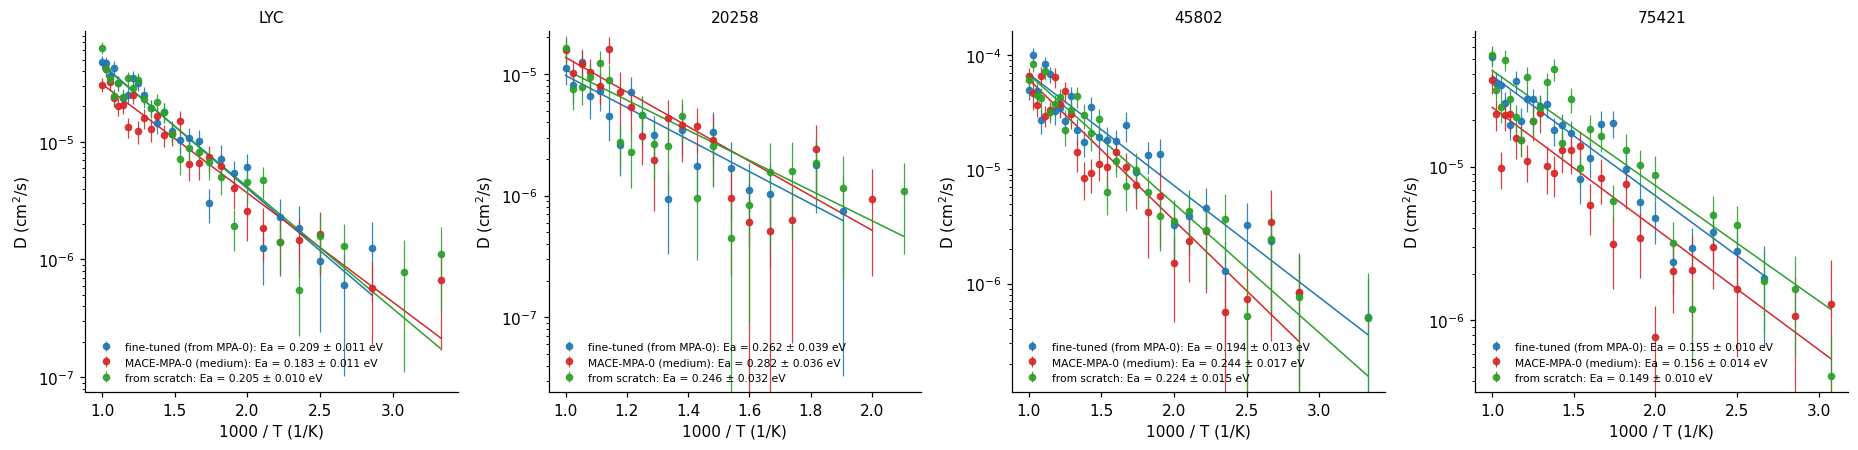

In [2]:
fig, axes = plt.subplots(1, 4, figsize=(17, 4.2))
for ax, (m, d) in zip(axes, docs.items()):
    for s, c in zip(d["series"], PALETTE):
        mr.arrhenius_plot(ax, s, c, label=s["label"].replace("MACE ", ""))
    ax.set_title(m); ax.legend(frameon=False, fontsize=7, loc="lower left")
fig.tight_layout(); save(fig, "md/mace_ft_vs_mpa0_vs_scratch_arrhenius")

## How complete are the runs?

Analyzed trajectory length at every temperature (400 ps minus 10 ps equilibration = 390 ps when complete).

'figures/md/mace_ft_vs_mpa0_vs_scratch_run_lengths.png'

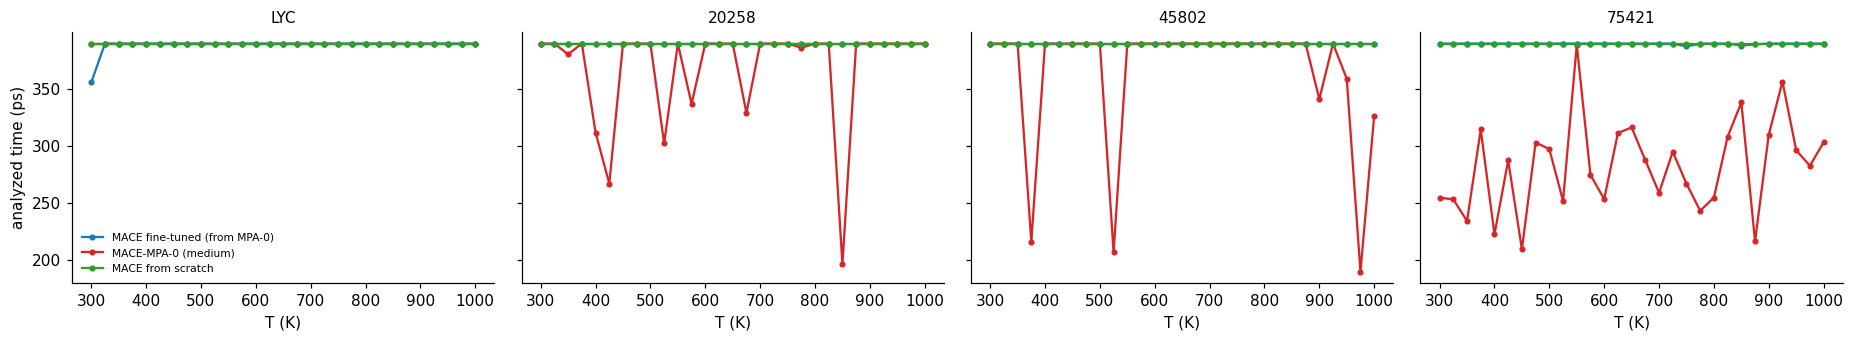

In [3]:
fig, axes = plt.subplots(1, 4, figsize=(17, 3.2), sharey=True)
for ax, (m, d) in zip(axes, docs.items()):
    for s, c in zip(d["series"], PALETTE):
        T = [r["temperature_K"] for r in s["temperatures"]]
        ax.plot(T, [r.get("analyzed_time_ps", 0) for r in s["temperatures"]], "o-", ms=3, color=c, label=s["label"])
    ax.set_title(m); ax.set_xlabel("T (K)")
axes[0].set_ylabel("analyzed time (ps)"); axes[0].legend(frameon=False, fontsize=7)
fig.tight_layout(); save(fig, "md/mace_ft_vs_mpa0_vs_scratch_run_lengths")

## Sensitivity to the fit choices

In [4]:
pd.concat({m: mr.fit_comparison(d, ["all (no framework melt)", "all", "all (unweighted)",
                                    "769-1000K (no framework melt)"]) for m, d in docs.items()})

all (no framework melt)    all  \
LYC   MACE fine-tuned (from MPA-0)                    0.209  0.209   
      MACE-MPA-0 (medium)                             0.183  0.183   
      MACE from scratch                               0.205  0.205   
20258 MACE fine-tuned (from MPA-0)                    0.262  0.262   
      MACE-MPA-0 (medium)                             0.282  0.282   
      MACE from scratch                               0.246  0.246   
45802 MACE fine-tuned (from MPA-0)                    0.194  0.194   
      MACE-MPA-0 (medium)                             0.244  0.244   
      MACE from scratch                               0.224  0.224   
75421 MACE fine-tuned (from MPA-0)                    0.155  0.155   
      MACE-MPA-0 (medium)                             0.156  0.156   
      MACE from scratch                               0.149  0.149   

                                    all (unweighted)  \
LYC   MACE fine-tuned (from MPA-0)             0.204   
      MACE-MPA-0 (medium)                      0.169   
      MACE from scratch                        0.174   
20258 MACE fine-tuned (from MPA-0)             0.236   
      MACE-MPA-0 (medium)                      0.286   
      MACE from scratch                        0.207   
45802 MACE fine-tuned (from MPA-0)             0.187   
      MACE-MPA-0 (medium)                      0.213   
      MACE from scratch                        0.198   
75421 MACE fine-tuned (from MPA-0)             0.161   
      MACE-MPA-0 (medium)                      0.145   
      MACE from scratch                        0.165   

                                    769-1000K (no framework melt)  
LYC   MACE fine-tuned (from MPA-0)                          0.177  
      MACE-MPA-0 (medium)                                   0.273  
      MACE from scratch                                     0.190  
20258 MACE fine-tuned (from MPA-0)                          0.345  
      MACE-MPA-0 (medium)                                   0.404  
      MACE from scratch                                     0.476  
45802 MACE fine-tuned (from MPA-0)                          0.205  
      MACE-MPA-0 (medium)                                   0.117  
      MACE from scratch                                     0.274  
75421 MACE fine-tuned (from MPA-0)                          0.158  
      MACE-MPA-0 (medium)                                   0.148  
      MACE from scratch                                     0.196

## Comparison with AIMD (PBE)

Each material's own AIMD data (the training data of its fine-tuned and from-scratch models) was analyzed
with the same code and fit settings: LYC at 500–900 K (`results/aimd_lyc.json`) and the Na conductors at
800–1300 K (`results/aimd_na_conductors.json`). The Na-conductor MD only reaches 1000 K, so its
E<sub>a</sub> in the AIMD window uses 800–1000 K and D ratios are given only at 800, 900 and 1000 K.

Ea in AIMD window (eV)  Ea std (eV)  \
      model                                                               
LYC   AIMD (PBE)                                     0.265        0.045   
      MACE fine-tuned (from MPA-0)                   0.198        0.018   
      MACE-MPA-0 (medium)                            0.158        0.020   
      MACE from scratch                              0.241        0.019   
20258 AIMD (PBE) 20258                               0.439        0.074   
      MACE fine-tuned (from MPA-0)                   0.331        0.122   
      MACE-MPA-0 (medium)                            0.347        0.114   
      MACE from scratch                              0.465        0.123   
45802 AIMD (PBE) 45802                               0.191        0.048   
      MACE fine-tuned (from MPA-0)                   0.257        0.070   
      MACE-MPA-0 (medium)                            0.088        0.071   
      MACE from scratch                              0.302        0.069   
75421 AIMD (PBE) 75421                               0.148        0.049   
      MACE fine-tuned (from MPA-0)                   0.185        0.059   
      MACE-MPA-0 (medium)                            0.238        0.083   
      MACE from scratch                              0.227        0.061   

                                      T used (K)  
      model                                       
LYC   AIMD (PBE)                     500-900 (5)  
      MACE fine-tuned (from MPA-0)  500-900 (17)  
      MACE-MPA-0 (medium)           500-900 (17)  
      MACE from scratch             500-900 (17)  
20258 AIMD (PBE) 20258              800-1300 (5)  
      MACE fine-tuned (from MPA-0)  800-1000 (9)  
      MACE-MPA-0 (medium)           800-1000 (9)  
      MACE from scratch             800-1000 (9)  
45802 AIMD (PBE) 45802              800-1300 (5)  
      MACE fine-tuned (from MPA-0)  800-1000 (9)  
      MACE-MPA-0 (medium)           800-1000 (9)  
      MACE from scratch             800-1000 (9)  
75421 AIMD (PBE) 75421              800-1300 (5)  
      MACE fine-tuned (from MPA-0)  800-1000 (9)  
      MACE-MPA-0 (medium)           800-1000 (9)  
      MACE from scratch             800-1000 (9)

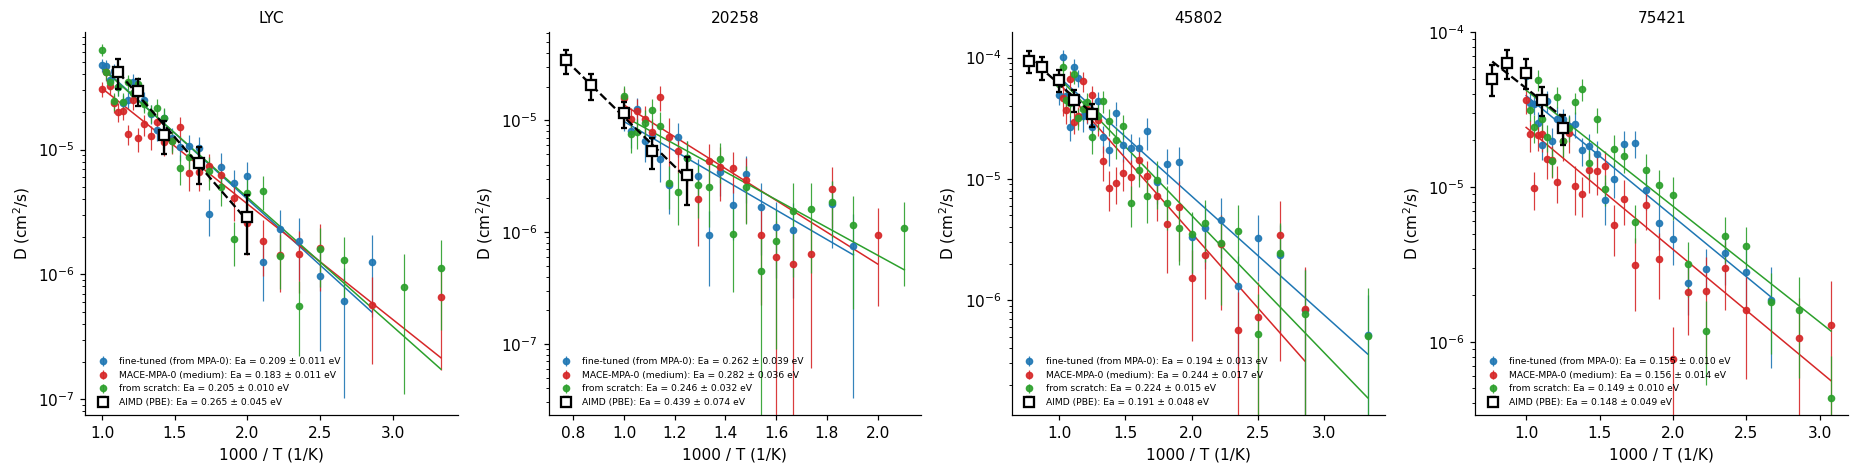

In [5]:
aimd = {"LYC": mr.series(mr.load("aimd_lyc"), "AIMD (PBE)")}
na = mr.load("aimd_na_conductors")
for m in ("20258", "45802", "75421"):
    aimd[m] = mr.series(na, f"AIMD (PBE) {m}")
fig, axes = plt.subplots(1, 4, figsize=(17, 4.4))
tabs, rats = {}, {}
for ax, (m, d) in zip(axes, docs.items()):
    for s, c in zip(d["series"], PALETTE):
        mr.arrhenius_plot(ax, s, c, label=s["label"].replace("MACE ", ""), show_melted=False)
    mr.aimd_overlay(ax, aimd[m])
    ax.set_title(m); ax.legend(frameon=False, fontsize=6, loc="lower left")
    tabs[m], rats[m] = mr.compare_to_aimd(d["series"], aimd[m])
fig.tight_layout(); save(fig, "md/mace_ft_vs_mpa0_vs_scratch_vs_aimd")
pd.concat(tabs)

In [6]:
pd.concat(rats).round(2)

D_FP/D_AIMD at 500 K  \
LYC   MACE fine-tuned (from MPA-0)                  1.39   
      MACE-MPA-0 (medium)                           1.27   
      MACE from scratch                             1.44   
20258 MACE fine-tuned (from MPA-0)                   NaN   
      MACE-MPA-0 (medium)                            NaN   
      MACE from scratch                              NaN   
45802 MACE fine-tuned (from MPA-0)                   NaN   
      MACE-MPA-0 (medium)                            NaN   
      MACE from scratch                              NaN   
75421 MACE fine-tuned (from MPA-0)                   NaN   
      MACE-MPA-0 (medium)                            NaN   
      MACE from scratch                              NaN   

                                    D_FP/D_AIMD at 600 K  \
LYC   MACE fine-tuned (from MPA-0)                  1.15   
      MACE-MPA-0 (medium)                           0.95   
      MACE from scratch                             1.16   
20258 MACE fine-tuned (from MPA-0)                   NaN   
      MACE-MPA-0 (medium)                            NaN   
      MACE from scratch                              NaN   
45802 MACE fine-tuned (from MPA-0)                   NaN   
      MACE-MPA-0 (medium)                            NaN   
      MACE from scratch                              NaN   
75421 MACE fine-tuned (from MPA-0)                   NaN   
      MACE-MPA-0 (medium)                            NaN   
      MACE from scratch                              NaN   

                                    D_FP/D_AIMD at 700 K  \
LYC   MACE fine-tuned (from MPA-0)                  1.24   
      MACE-MPA-0 (medium)                           0.95   
      MACE from scratch                             1.24   
20258 MACE fine-tuned (from MPA-0)                   NaN   
      MACE-MPA-0 (medium)                            NaN   
      MACE from scratch                              NaN   
45802 MACE fine-tuned (from MPA-0)                   NaN   
      MACE-MPA-0 (medium)                            NaN   
      MACE from scratch                              NaN   
75421 MACE fine-tuned (from MPA-0)                   NaN   
      MACE-MPA-0 (medium)                            NaN   
      MACE from scratch                              NaN   

                                    D_FP/D_AIMD at 800 K  \
LYC   MACE fine-tuned (from MPA-0)                  0.84   
      MACE-MPA-0 (medium)                           0.62   
      MACE from scratch                             0.84   
20258 MACE fine-tuned (from MPA-0)                  1.41   
      MACE-MPA-0 (medium)                           1.87   
      MACE from scratch                             1.64   
45802 MACE fine-tuned (from MPA-0)                  1.15   
      MACE-MPA-0 (medium)                           0.88   
      MACE from scratch                             1.04   
75421 MACE fine-tuned (from MPA-0)                  1.03   
      MACE-MPA-0 (medium)                           0.64   
      MACE from scratch                             1.14   

                                    D_FP/D_AIMD at 900 K  \
LYC   MACE fine-tuned (from MPA-0)                  0.83   
      MACE-MPA-0 (medium)                           0.58   
      MACE from scratch                             0.82   
20258 MACE fine-tuned (from MPA-0)                  1.30   
      MACE-MPA-0 (medium)                           1.78   
      MACE from scratch                             1.47   
45802 MACE fine-tuned (from MPA-0)                  1.18   
      MACE-MPA-0 (medium)                           0.99   
      MACE from scratch                             1.12   
75421 MACE fine-tuned (from MPA-0)                  0.87   
      MACE-MPA-0 (medium)                           0.54   
      MACE from scratch                             0.95   

                                    D_FP/D_AIMD at 1000 K  \
LYC   MACE fine-tuned (from MPA-0)                    NaN   
      MAC

## Findings

* **Fine-tuning lowers force errors in every material.** The final validation force MAE of the
  fine-tuned model is 5.2 / 16.2 / 25.4 / 13.6 meV/Å (LYC / 20258 / 45802 / 75421), against
  7.6 / 23.3 / 31.1 / 20.5 meV/Å for the model trained from scratch on the same data.
* **Fine-tuned and from-scratch models agree on E<sub>a</sub>** within 1.5 combined standard deviations
  in all four materials (LYC 0.209 vs 0.205 eV, 20258 0.262 vs 0.246, 45802 0.194 vs 0.224, 75421 0.155
  vs 0.149 eV): both models trained on the material's own AIMD data give a consistent answer.
* **The foundation model can deviate.** MACE-MPA-0 without fine-tuning gives a lower E<sub>a</sub> for
  LYC (0.183 eV) and a higher one for 45802 (0.244 eV vs 0.194 eV fine-tuned, σ(300 K) 2.2 vs
  9.6 mS/cm); for 75421 (0.156 eV) and 20258 (0.282 ± 0.036 eV) it agrees within the uncertainty.
* **20258 has the largest uncertainty** (±0.03–0.04 eV): Na diffusion is slow, and below 475–525 K
  the MSD does not grow enough in 400 ps for a fit, leaving 19–21 temperatures.
* **Narrow high-temperature windows are unreliable here.** Fits over 769–1000 K (10 temperatures) move
  E<sub>a</sub> by up to 0.23 eV (20258 from scratch: 0.246 vs 0.476 eV), so the full-range fit is used.
* No framework melting occurred in any of these runs (29 temperatures × 3 models × 4 materials).

**Against AIMD (PBE).** The AIMD data each model was trained on, analyzed the same way:

* **Fine-tuned MACE reproduces the AIMD diffusivity in all four materials:** D within a factor of 1.41
  of AIMD at every temperature where both exist (LYC 0.83–1.39, 20258 0.84–1.41, 45802 1.05–1.18,
  75421 0.71–1.03). From-scratch MACE is similar (within a factor of 1.64).
* **MACE-MPA-0 without fine-tuning deviates more** in three of the four: LYC 0.58–1.27, 20258
  1.18–1.87, 75421 0.44–0.64 (2.3× too slow at 1000 K). For 45802 it is as close as the trained
  models (0.88–0.99).
* **LYC E<sub>a</sub> over the AIMD window (500–900 K):** AIMD 0.265 ± 0.045 eV, from scratch
  0.241 ± 0.019, fine-tuned 0.198 ± 0.018, MACE-MPA-0 0.158 ± 0.020 eV.
* For the Na conductors the MD (300–1000 K) and AIMD (800–1300 K) overlap only at 800–1000 K, so the
  E<sub>a</sub> comparison there rests on three AIMD points and has uncertainties of ±0.07–0.12 eV; the
  diffusivity ratios above are the more reliable comparison.